# Notebook evaluation YOLO vs. Ground Truth

This notebook evaluates YOLO vs. the Ground Truth. The Ground Truth Data was made within Label Studio and saved as Brush labels to Numpy. Since the numerical order of the task-id (ID of the GT labelled frame) does not correspond to the numerical order of the frame numbers, the correct frame number order is saved in a ```.txt``` file. E.g. a ```.txt``` file for the frames of fishvideoX contains the line ```10, 30, 20```. Since we also do not want to include the neighboured fish tanks in the evaluation, the crop box coordinates (created with ```tank_annotator.py```) are also used.

In [18]:

from collections import defaultdict
import json
import os
from pathlib import Path
import re
import warnings
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pycocotools.mask as mask_utils
from tidecv import TIDE, datasets
import torch
from ultralytics import YOLO
warnings.filterwarnings("ignore")

# ======================= CONFIGURATION =======================
GT_LABELS_DIR = Path("./gt_labels_new_tofill") #Path to the Ground Truth Labels
RECORDINGS_DIR = Path("./recordings_counted") # Path to the frames directory. The frames directory contains folder for each video containing the frames
MODEL_PATH = "./runs/segment/train-19/weights/best.pt"  #Path to the YOLO weights
CONF_THRESHOLD = 0.25  # Threshold for visualization
TIDE_CONF = 0.10  # TIDE threshold

TIDE_OUT_DIR = Path("./tide_output_plots")
TIDE_OUT_DIR.mkdir(parents=True, exist_ok=True)
# =============================================================


# loads the box to which a specific frame should be cropped. Is used so neighboured tanks and their fish are not falsely included in the evaulation
def load_crop_box_from_txt(
    finished_folder, video_prefix, frame_nr, task_id, img_shape
):
    h_orig, w_orig = img_shape[:2]
    candidates = [
        finished_folder / f"{video_prefix}_{frame_nr:04d}_cut.txt",
        finished_folder / f"{video_prefix}_{frame_nr}_cut.txt",
        finished_folder / f"{video_prefix}_task-{task_id}_cut.txt",
        finished_folder / f"task-{task_id}_cut.txt",
    ]
    for cand in candidates:
        if cand.exists():
            with open(cand, "r") as f:
                for line in f:
                    line = line.strip()
                    if line and not line.startswith("#"):
                        parts = [int(x.strip()) for x in line.split(",")]
                        if len(parts) == 4:
                            x1, y1, x2, y2 = parts
                            x1 = max(0, min(w_orig, x1))
                            y1 = max(0, min(h_orig, y1))
                            x2 = max(0, min(w_orig, x2))
                            y2 = max(0, min(h_orig, y2))
                            if x2 > x1 and y2 > y1:
                                return x1, y1, x2, y2

    print(
        f"[!] Keine _cut.txt für {video_prefix} Frame {frame_nr:04d} (Task-{task_id}) gefunden -> Nutze volles Bild!"
    )
    return 0, 0, w_orig, h_orig


# extracts the masks from the yolo prediction
def get_pred_masks(yolo_result, target_h, target_w):
    if yolo_result.masks is None or len(yolo_result.masks) == 0:
        return []
    raw_masks = yolo_result.masks.data.cpu().numpy()
    masks = []
    for m in raw_masks:
        m = (m > 0.5).astype(np.uint8)
        if m.shape[:2] != (target_h, target_w):
            m = cv2.resize(
                m, (target_w, target_h), interpolation=cv2.INTER_NEAREST
            )
        masks.append(m)
    return masks


# get the IoU between 2 masks
def mask_iou(m1, m2):
    inter = np.logical_and(m1, m2).sum()
    union = np.logical_or(m1, m2).sum()
    return float(inter / union) if union > 0 else 0.0


# get the IoU for the whole image
def compute_image_iou(gt_masks_list, pred_masks_list):
    if len(gt_masks_list) == 0 and len(pred_masks_list) == 0:
        return 1.0
    if len(gt_masks_list) == 0 or len(pred_masks_list) == 0:
        return 0.0
    combined_gt = np.clip(np.sum(gt_masks_list, axis=0), 0, 1).astype(np.uint8)
    combined_pred = np.clip(np.sum(pred_masks_list, axis=0), 0, 1).astype(
        np.uint8
    )
    inter = np.logical_and(combined_gt, combined_pred).sum()
    union = np.logical_or(combined_gt, combined_pred).sum()
    return float(inter / union) if union > 0 else 0.0

             🚀 START INFERENCE & TIDE EVALUATION
[+] number of found mapping files: 14
[+] 102 frames loaded, cropped and segmentation generated by yolo.

--- 1. TIDE Mask-Evaluation (Segmentation) ---

--- 2. TIDE Box-Evaluation (Bounding Box) ---

              TIDE EVALUATION
-- YOLO Mask-Seg --

mask AP @ 50: 79.22

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     3.63     0.00     0.27     6.98     7.09  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------------------
   dAP       8.90      10.54  

-- YOLO Box-Det --

bbox AP @ 50: 76.00

                         Main Errors
  Type      Cls      Loc     Both     Dupe      Bkg     Miss  
-------------------------------------------------------------
   dAP     0.00     7.00     0.00     0.26     6.55     6.31  

        Special Error
  Type   FalsePos   FalseNeg  
-----------------

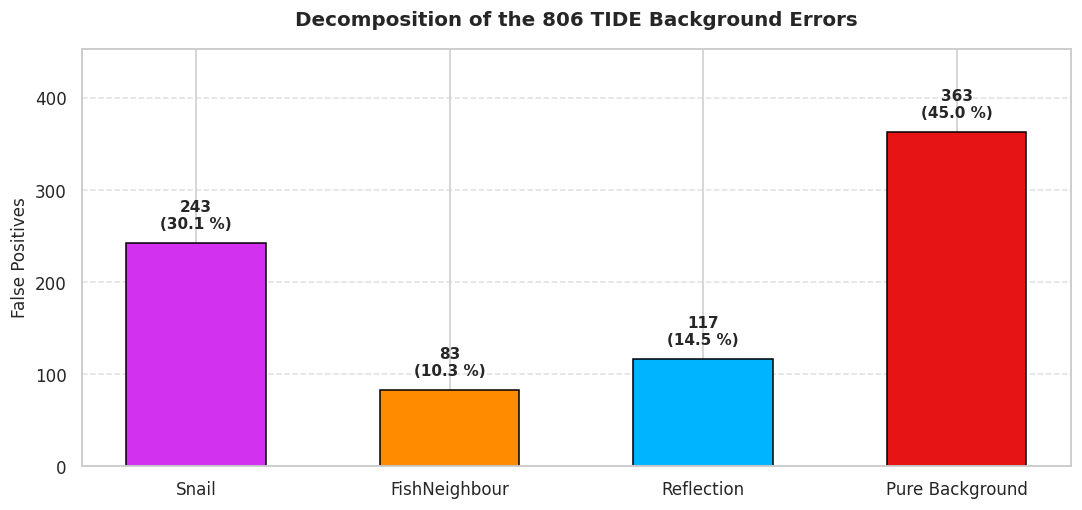

In [19]:
print("=" * 75)
print("             🚀 START INFERENCE & TIDE EVALUATION")
print("=" * 75)

model = YOLO(MODEL_PATH)
evaluated_samples = []

# loads the mapping for the ground truth label files to fishvideo and frame.
txt_files = sorted(list(GT_LABELS_DIR.glob("fishvideo*.txt")))

print(f"[+] number of found mapping files: {len(txt_files)}")

for txt_file in txt_files:
    #----------loading the GT labels----------
    video_prefix = txt_file.stem.replace("_finished", "")

    finished_folder = GT_LABELS_DIR / f"{video_prefix}_finished"
    if not finished_folder.exists():
        print(f"folder {finished_folder} not found")
    #----------loading the videoframes----------
    frames_folder = RECORDINGS_DIR / f"frames_{video_prefix}"
    if not frames_folder.exists():
        frames_folder = RECORDINGS_DIR / video_prefix

    if not finished_folder.exists() or not frames_folder.exists():
        print(
            f"[!] {video_prefix}: not found"
        )
        continue

    # 1. get the frames mapping. in this case the numerical ordner of the GT labels number does not correspond to the numerical ordner of the frames number
    with open(txt_file, "r") as f:
        content = f.read()
    frame_numbers = [int(num) for num in re.findall(r"\d+", content)]

    # 2. group the gt labels to frames
    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = defaultdict(lambda: defaultdict(list))
    for mf in all_mask_files:
        match = re.search(r"task-(\d+)", mf.name)
        if match:
            task_id = int(match.group(1))
            #get and group the gt labels (fish, fish_neighbour, reflection, snail) 
            name_lower = mf.name.lower()
            if (
                "tag-fisch" in name_lower
                or "tag-fish-" in name_lower
                or "tag-fish." in name_lower
                or name_lower.endswith("-fish.npy")
            ):
                task_groups[task_id]["fish"].append(mf)
            elif "tag-snail" in name_lower:
                task_groups[task_id]["snail"].append(mf)
            elif "tag-fishneighbour" in name_lower:
                task_groups[task_id]["neighbour"].append(mf)
            elif "tag-reflection" in name_lower:
                task_groups[task_id]["reflection"].append(mf)

    sorted_task_ids = sorted(task_groups.keys())
    min_len = min(len(frame_numbers), len(sorted_task_ids))

    # 3. load each frame, then apply the crop box to the frame, then apply yolo inference on the frame
    for frame_nr, task_id in zip(
        frame_numbers[:min_len], sorted_task_ids[:min_len]
    ):
        img_name = f"{frame_nr:04d}.jpg"
        img_path = frames_folder / img_name
        if not img_path.exists():
            img_path = frames_folder / f"{frame_nr}.jpg"
        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h_orig, w_orig = img.shape[:2]

        # load crop box
        x1, y1, x2, y2 = load_crop_box_from_txt(
            finished_folder, video_prefix, frame_nr, task_id, img.shape
        )
        img_crop = img[y1:y2, x1:x2]
        h_crop, w_crop = img_crop.shape[:2]

        def load_cropped_masks(file_list):
            masks = []
            for mf in file_list:
                data = np.load(mf)
                m = (
                    data[list(data.keys())[0]] if mf.suffix == ".npz" else data
                ).astype(np.uint8)
                if m.ndim == 3:
                    m = m.squeeze()
                if m.shape[:2] != (h_orig, w_orig):
                    m = cv2.resize(
                        m, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST
                    )
                m_crop = (m[y1:y2, x1:x2] > 0).astype(np.uint8)
                if m_crop.sum() > 0:
                    masks.append(m_crop)
            return masks

        gt_fish_masks = load_cropped_masks(task_groups[task_id]["fish"])
        distractor_masks = {
            "snail": load_cropped_masks(task_groups[task_id]["snail"]),
            "neighbour": load_cropped_masks(task_groups[task_id]["neighbour"]),
            "reflection": load_cropped_masks(
                task_groups[task_id]["reflection"]
            ),
        }

        # YOLO inference
        results = model.predict(
            source=img_crop,
            conf=CONF_THRESHOLD,
            retina_masks=True,
            verbose=False,
        )
        pred_masks_list = get_pred_masks(results[0], h_crop, w_crop)
        iou = compute_image_iou(gt_fish_masks, pred_masks_list)

        evaluated_samples.append(
            {
                "video": video_prefix,
                "task_id": task_id,
                "frame": frame_nr,
                "img_path": img_path,
                "img_crop": img_crop,
                "gt_fish_masks": gt_fish_masks,
                "distractor_masks": distractor_masks,
                "pred_masks": pred_masks_list,
                "num_gt": len(gt_fish_masks),
                "num_pred": (
                    len(results[0].boxes)
                    if results[0].boxes is not None
                    else 0
                ),
                "iou": iou,
                "crop_coords": (x1, y1, x2, y2),
                "h_crop": h_crop,
                "w_crop": w_crop,
            }
        )

print(
    f"[+] {len(evaluated_samples)} frames loaded, cropped and segmentation generated by yolo.\n"
)

# ---------------------------------------------------------
# TIDE EVALUATION
# ---------------------------------------------------------
gt_coco = {
    "images": [],
    "annotations": [],
    "categories": [{"id": 1, "name": "fish", "supercategory": "animal"}],
}
pred_coco = []
ann_id_counter = 1

for img_id, sample in enumerate(evaluated_samples, 1):
    h_crop, w_crop = sample["h_crop"], sample["w_crop"]
    gt_coco["images"].append(
        {
            "id": img_id,
            "file_name": f"{sample['video']}_{sample['frame']:04d}.jpg",
            "width": w_crop,
            "height": h_crop,
        }
    )

    for inst_mask in sample["gt_fish_masks"]:
        if inst_mask.sum() == 0:
            continue
        rle = mask_utils.encode(np.asfortranarray(inst_mask))
        rle["counts"] = rle["counts"].decode("utf-8")
        bbox = mask_utils.toBbox(rle).tolist()
        area = float(mask_utils.area(rle))

        contours, _ = cv2.findContours(
            inst_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        polygons = [
            c.reshape(-1, 2).ravel().tolist() for c in contours if len(c) >= 3
        ]

        gt_coco["annotations"].append(
            {
                "id": ann_id_counter,
                "image_id": img_id,
                "category_id": 1,
                "segmentation": polygons if len(polygons) > 0 else rle,
                "area": area,
                "bbox": bbox,
                "iscrowd": 0,
            }
        )
        ann_id_counter += 1

    # YOLO predicitons for TIDE (with TIDE_CONF = 0.10)
    tide_res = model.predict(
        source=sample["img_crop"],
        conf=TIDE_CONF,
        retina_masks=True,
        verbose=False,
    )
    tide_preds = get_pred_masks(tide_res[0], h_crop, w_crop)

    if tide_res[0].boxes is not None and len(tide_preds) > 0:
        boxes = tide_res[0].boxes.xywh.cpu().numpy()
        confs = tide_res[0].boxes.conf.cpu().numpy()
        for bin_pred, box, conf in zip(tide_preds, boxes, confs):
            if bin_pred.sum() == 0:
                continue
            x_c, y_c, bw, bh = box
            top_x = max(0, x_c - bw / 2)
            top_y = max(0, y_c - bh / 2)
            rle_pred = mask_utils.encode(np.asfortranarray(bin_pred))
            rle_pred["counts"] = rle_pred["counts"].decode("utf-8")
            pred_coco.append(
                {
                    "image_id": img_id,
                    "category_id": 1,
                    "bbox": [
                        float(top_x),
                        float(top_y),
                        float(bw),
                        float(bh),
                    ],
                    "score": float(conf),
                    "segmentation": rle_pred,
                }
            )

gt_json = TIDE_OUT_DIR / "tide_gt_temp.json"
pred_json = TIDE_OUT_DIR / "tide_pred_temp.json"
with open(gt_json, "w") as f:
    json.dump(gt_coco, f)
with open(pred_json, "w") as f:
    json.dump(pred_coco, f)

tide = TIDE()
gt_dataset = datasets.COCO(str(gt_json))
pred_dataset = datasets.COCOResult(str(pred_json))

print("--- 1. TIDE Mask-Evaluation (Segmentation) ---")
tide.evaluate(gt_dataset, pred_dataset, mode=TIDE.MASK, name="YOLO Mask-Seg")

print("\n--- 2. TIDE Box-Evaluation (Bounding Box) ---")
tide.evaluate(gt_dataset, pred_dataset, mode=TIDE.BOX, name="YOLO Box-Det")

print("\n" + "=" * 75)
print("              TIDE EVALUATION")
print("=" * 75)
tide.summarize()
tide.plot(out_dir=str(TIDE_OUT_DIR))
print(f"[+] TIDE-Plots saved in: {TIDE_OUT_DIR.resolve()}\n")

# ---------------------------------------------------------
# FEINAUFTEILUNG DES BACKGROUND-FEHLERS
# ---------------------------------------------------------
print("=" * 75)
print("     DECOMPOSE THE BACKGROUND ERRORS")
print("=" * 75)

bg_breakdown = {
    "Snail": 0,
    "Fish_Neighbour": 0,
    "Reflection": 0,
    "Background": 0,
}
true_fish_matches = 0
total_predictions = 0

for sample in evaluated_samples:
    gt_fishes = sample["gt_fish_masks"]
    distractors = sample["distractor_masks"]
    for pred_m in sample["pred_masks"]:
        total_predictions += 1
        if any(mask_iou(pred_m, gt_f) >= 0.5 for gt_f in gt_fishes):
            true_fish_matches += 1
            continue
        best_cat = "Background"
        max_iou = 0.10
        for dist_m in distractors.get("snail", []):
            if mask_iou(pred_m, dist_m) > max_iou:
                max_iou = mask_iou(pred_m, dist_m)
                best_cat = "Snail"
        for dist_m in distractors.get("neighbour", []):
            if mask_iou(pred_m, dist_m) > max_iou:
                max_iou = mask_iou(pred_m, dist_m)
                best_cat = "Fish_Neighbour"
        for dist_m in distractors.get("reflection", []):
            if mask_iou(pred_m, dist_m) > max_iou:
                max_iou = mask_iou(pred_m, dist_m)
                best_cat = "Reflection"
        bg_breakdown[best_cat] += 1

total_fp = total_predictions - true_fish_matches
print(f"Total predictions:               {total_predictions}")
print(
    f"  └── Correct fish segmentations(TP):  {true_fish_matches} ({true_fish_matches/max(1, total_predictions)*100:.1f} %)"
)
print(
    f"  └── Background errors (FP): {total_fp} ({total_fp/max(1, total_predictions)*100:.1f} %)\n"
)
print("-" * 75)
print(
    f"{'Interference Categories':<35} | {'Number of FP':<10} | {'Proportion Background Error':<25}"
)
print("-" * 75)
for cat_name, cnt in bg_breakdown.items():
    pct = (cnt / max(1, total_fp)) * 100
    print(f"{cat_name:<35} | {cnt:>8}   | {pct:>22.1f} %")
print("-" * 75)
print(f"{'TOTAL BACKGROUND ERROR':<35} | {total_fp:>8}   | {'100.0 %':>23}")
print("=" * 75)

# Plot der Background-Zerlegung
categories = [
    "Snail",
    "FishNeighbour",
    "Reflection",
    "Pure Background",
]
counts = [
    bg_breakdown["Snail"],
    bg_breakdown["Fish_Neighbour"],
    bg_breakdown["Reflection"],
    bg_breakdown["Background"],
]
colors = ["#d232f0", "#ff8c00", "#00b4ff", "#e61414"]

plt.figure(figsize=(10, 4.8), dpi=110)
bars = plt.bar(
    categories, counts, color=colors, edgecolor="black", width=0.55
)
plt.title(
    f"Decomposition of the {total_fp} TIDE Background Errors",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.ylabel("False Positives", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
for bar in bars:
    h = bar.get_height()
    pct = (h / max(1, total_fp)) * 100
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        h + max(0.5, total_fp * 0.015),
        f"{h}\n({pct:.1f} %)",
        ha="center",
        va="bottom",
        fontweight="bold",
        fontsize=10,
    )
plt.ylim(0, max(counts) * 1.25 if max(counts) > 0 else 10)
plt.tight_layout()
plt.show()

# Background Error Visualization

Now we want to inspect the background errors on the best and worst N frames by means of the IoU


       🏆 TOP 5 BEST FRAMES (highest IoU)


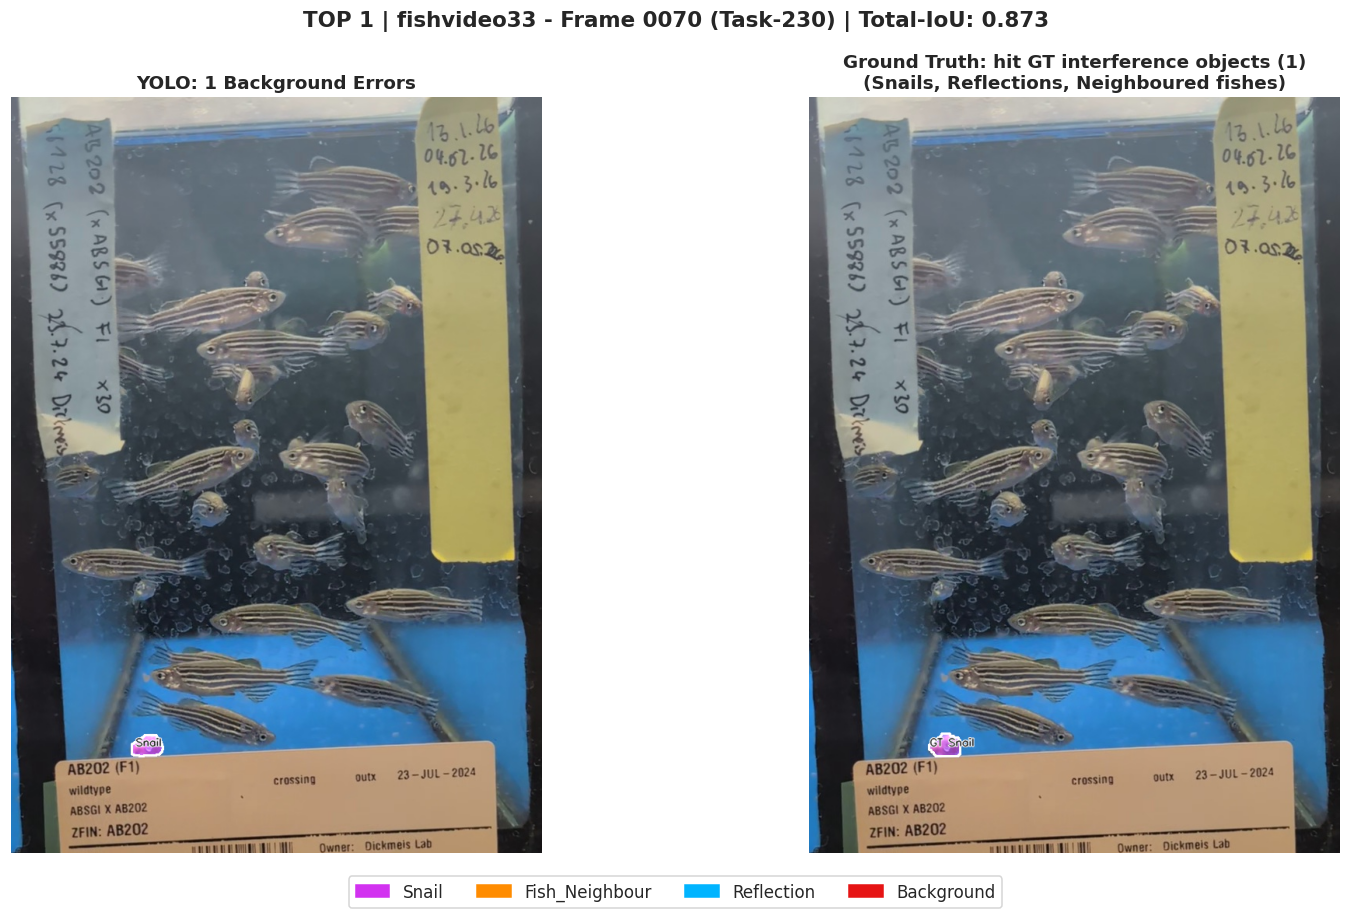

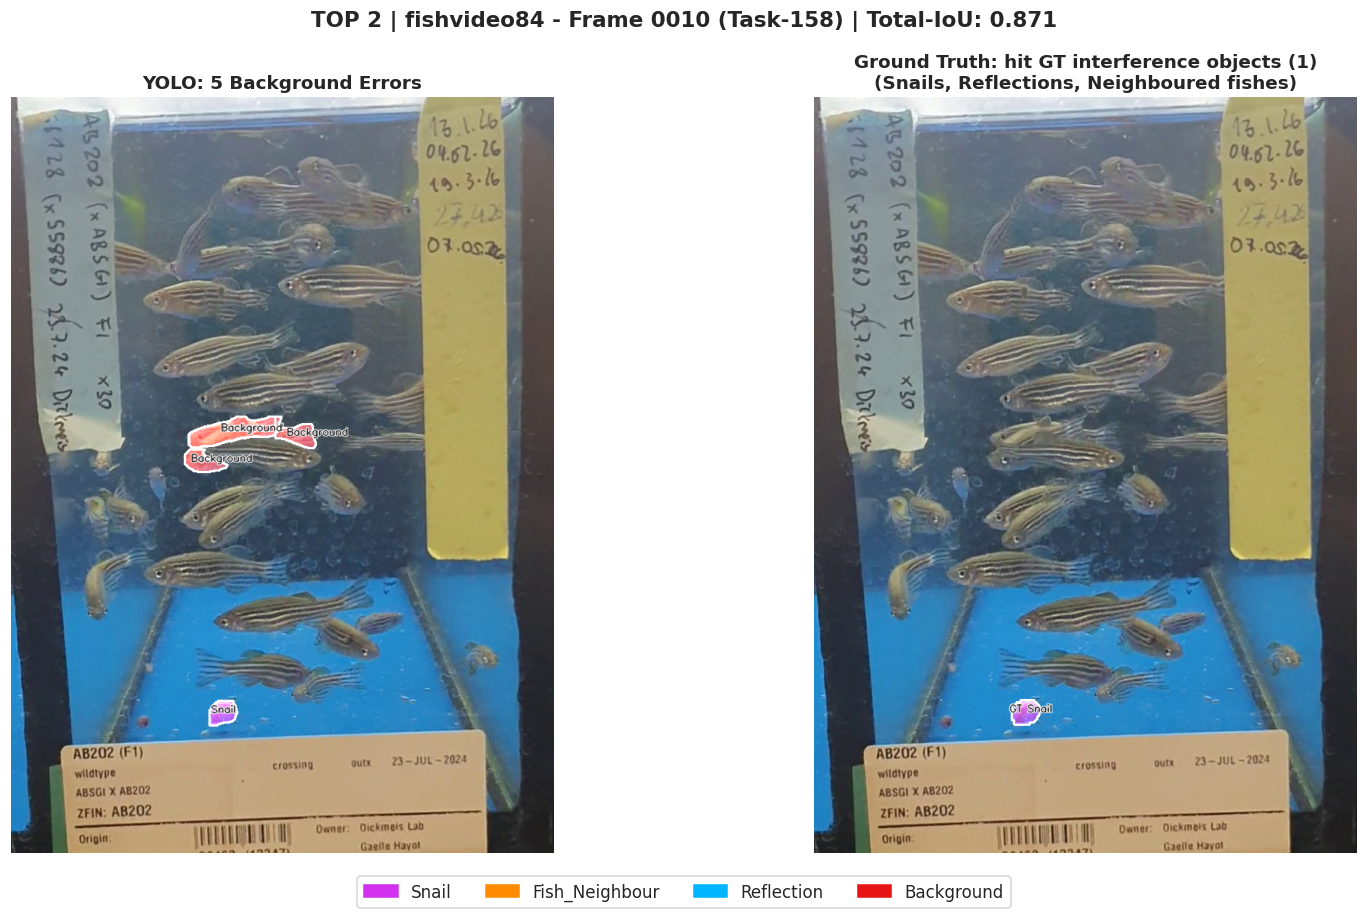

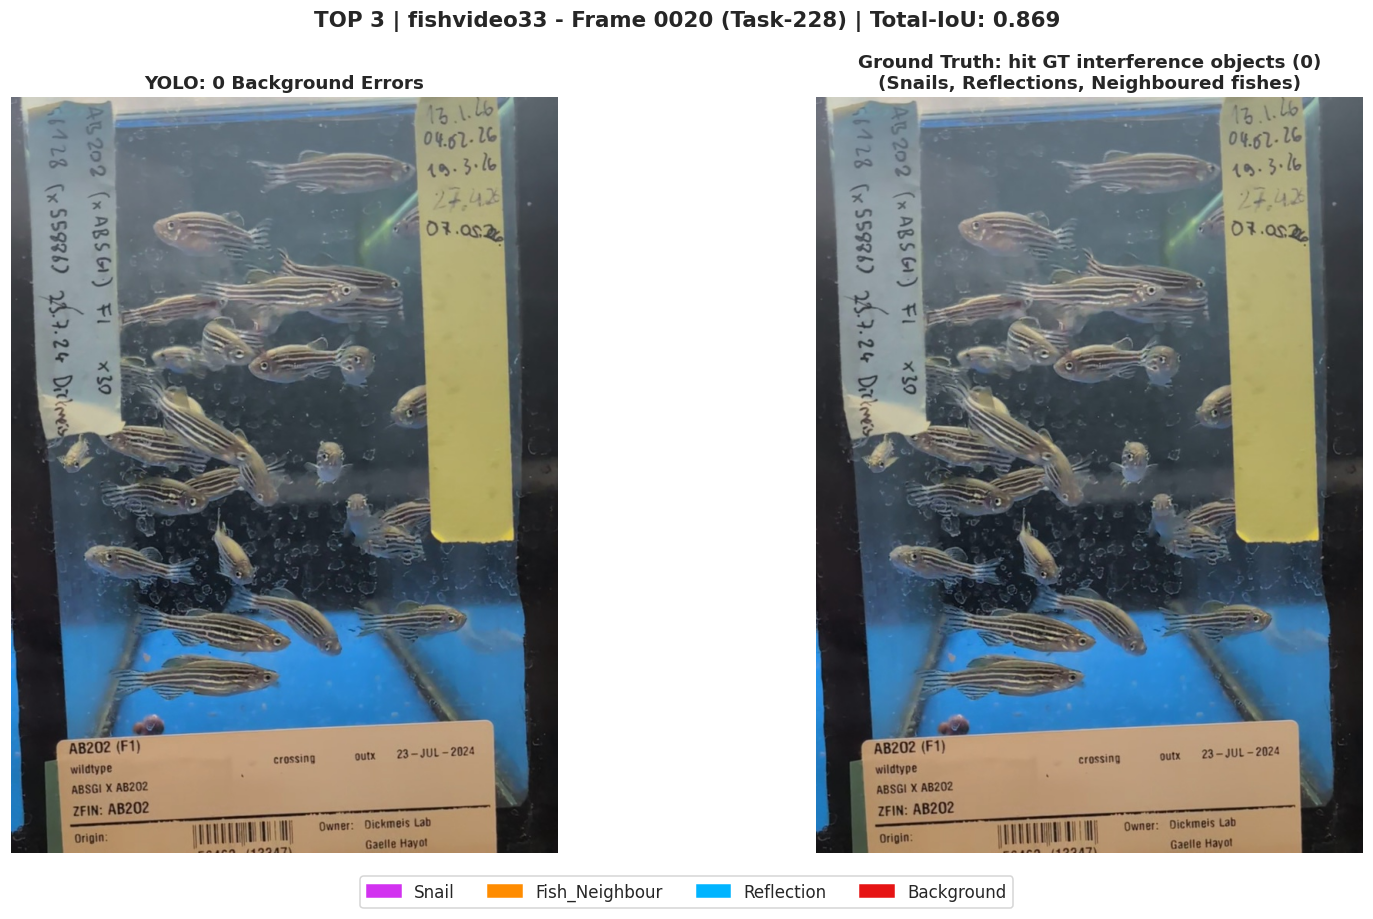

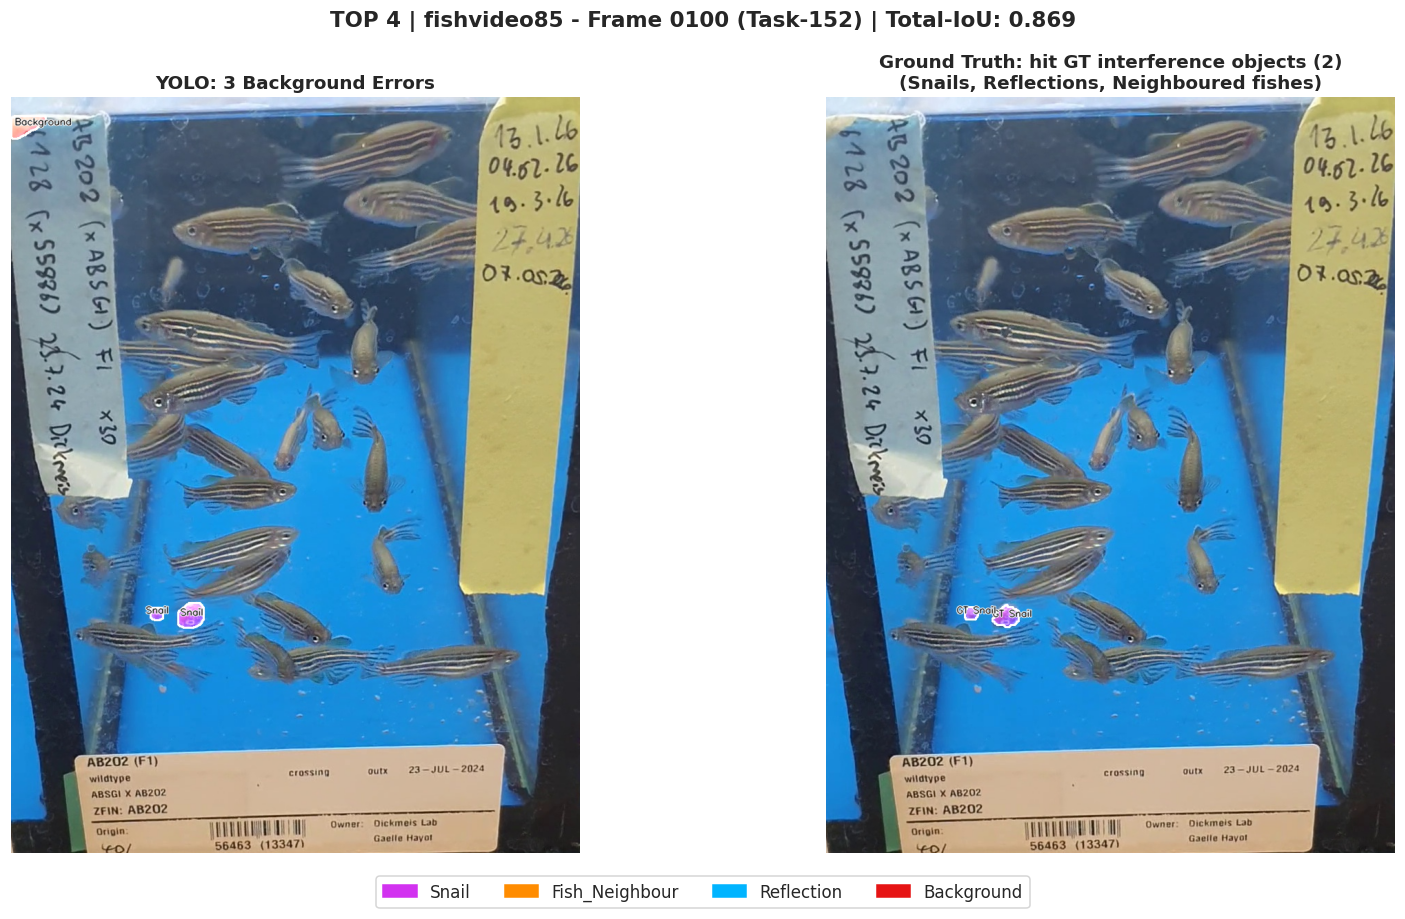

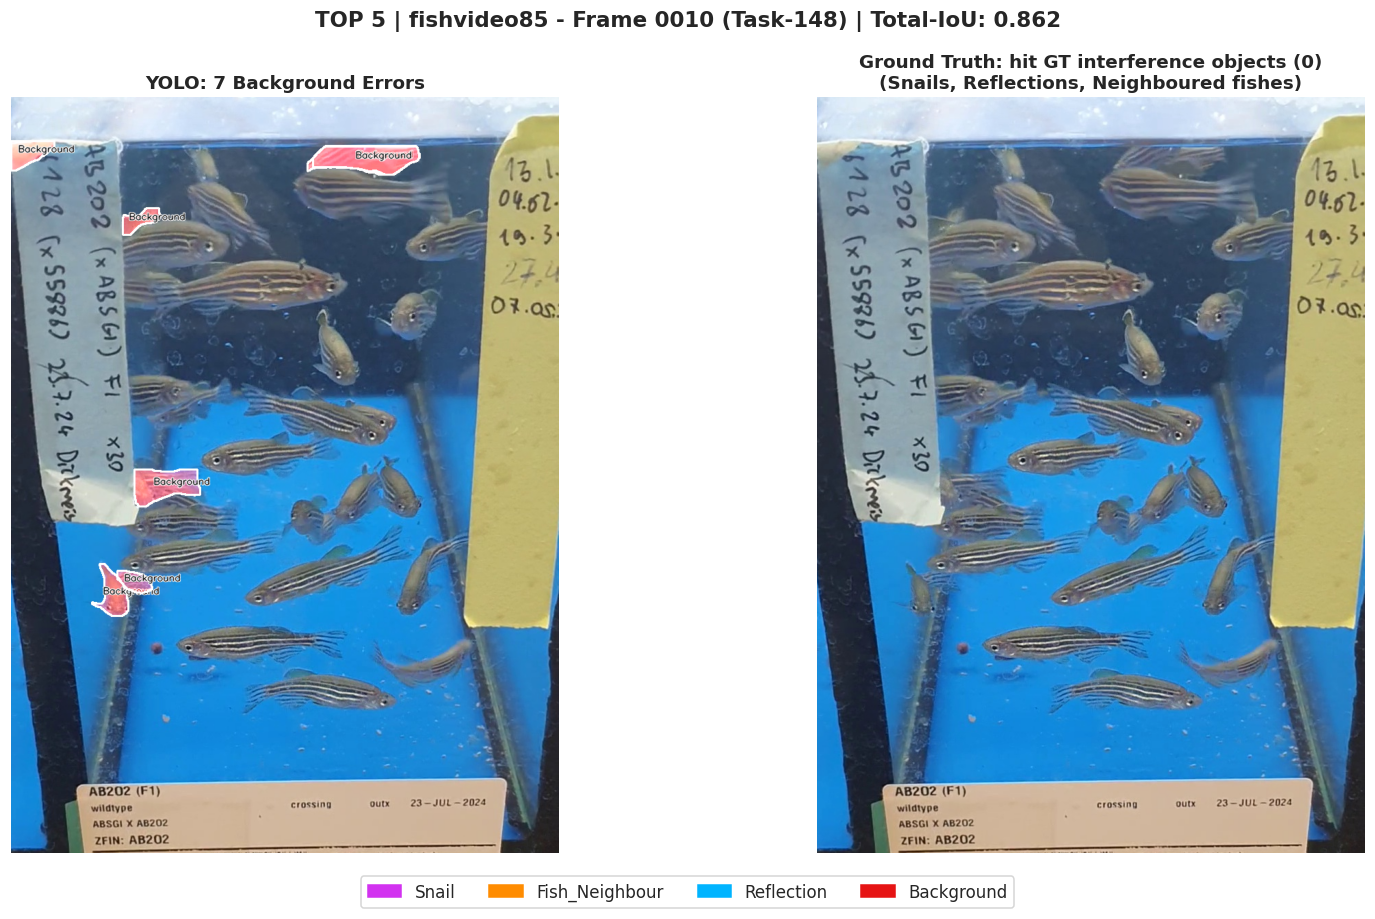


       ⚠️ FLOP 5 WORST FRAMES (lowest IoU)


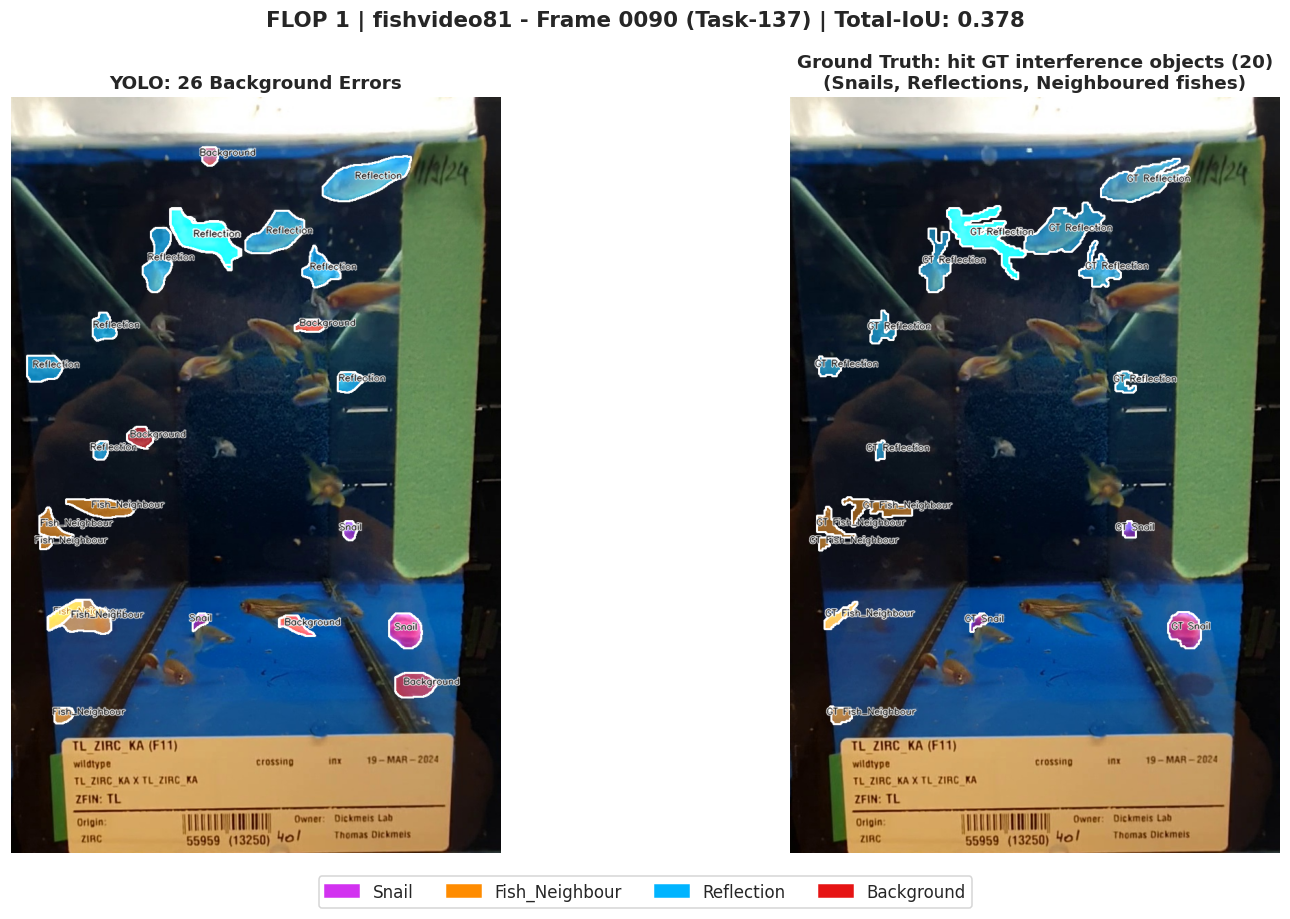

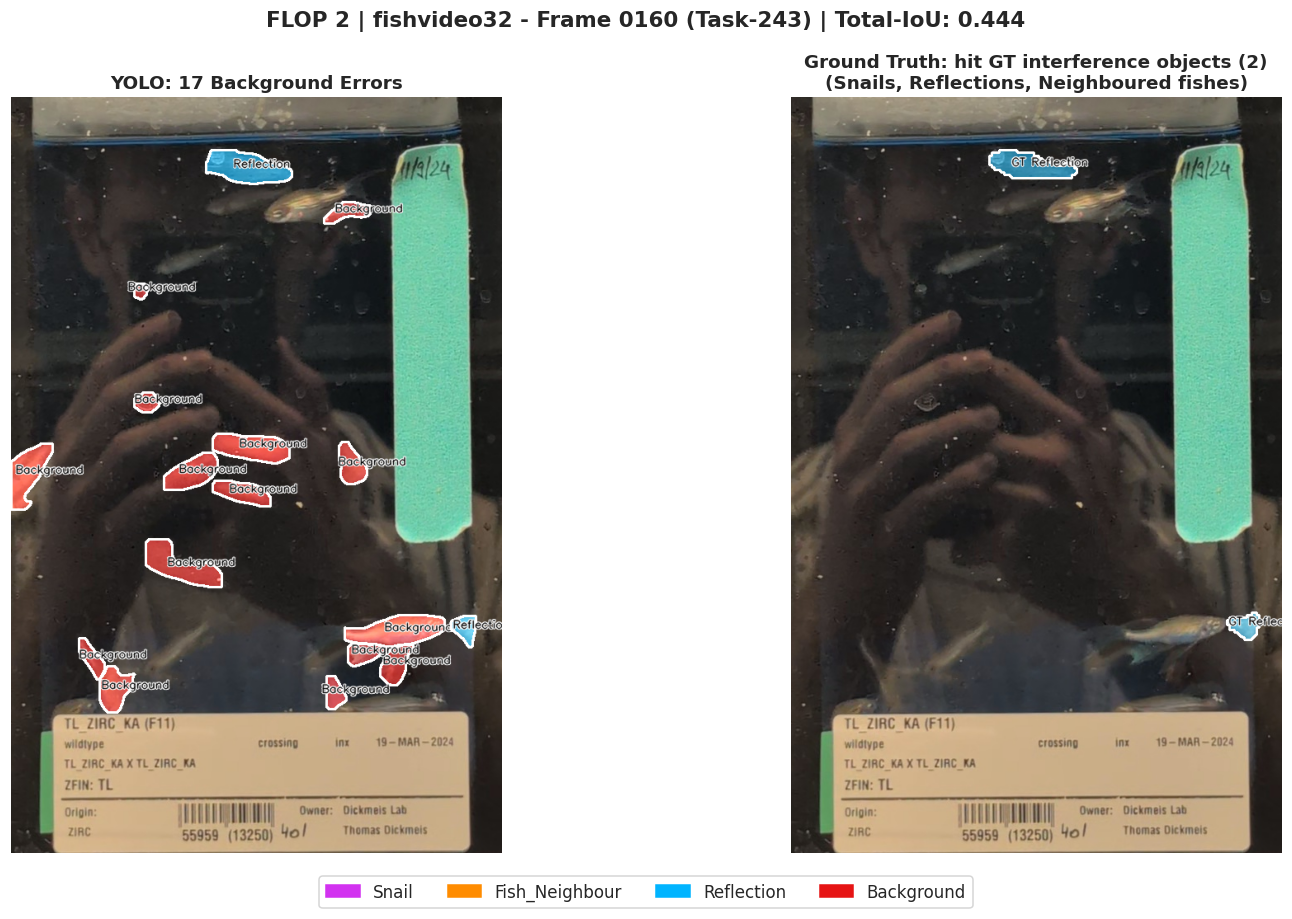

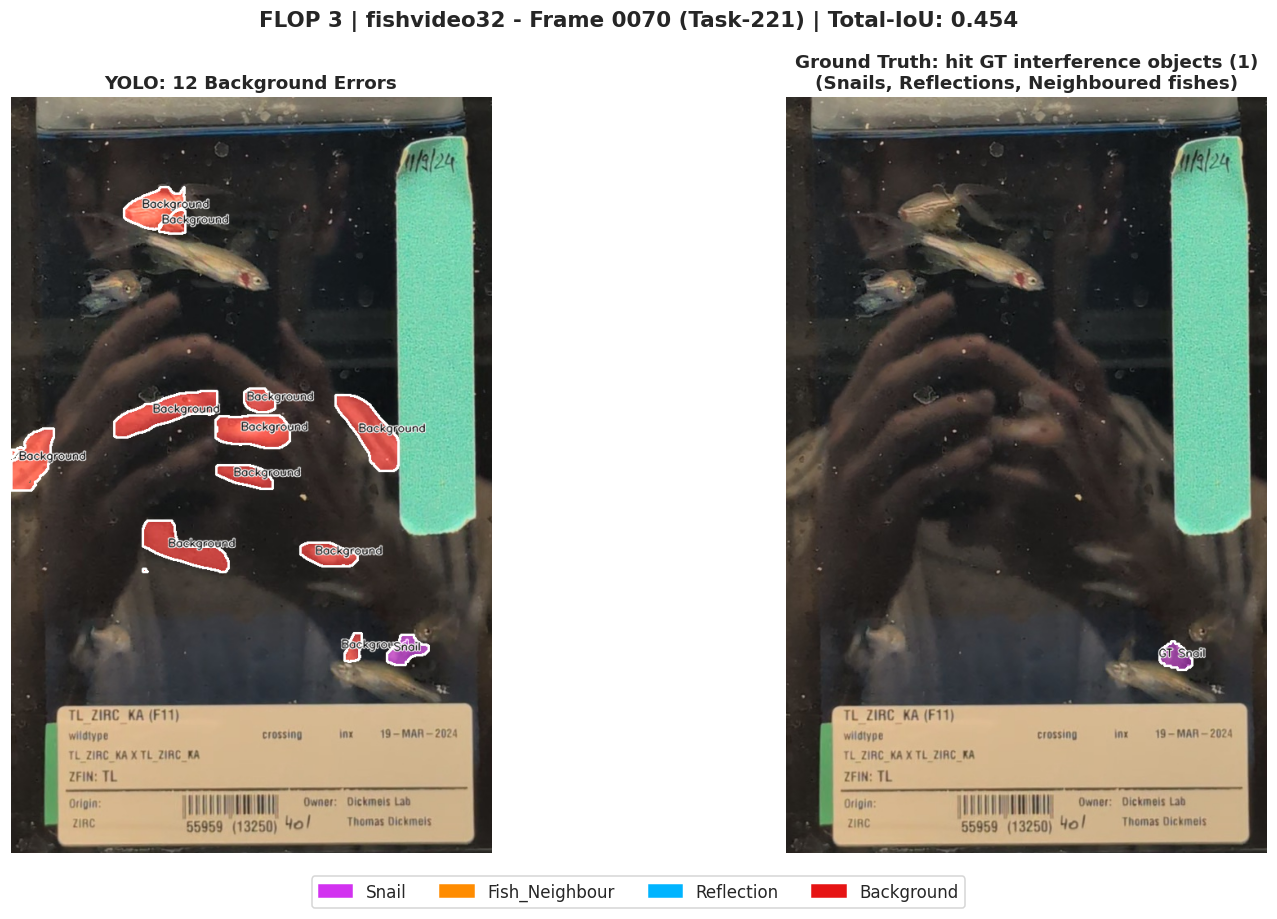

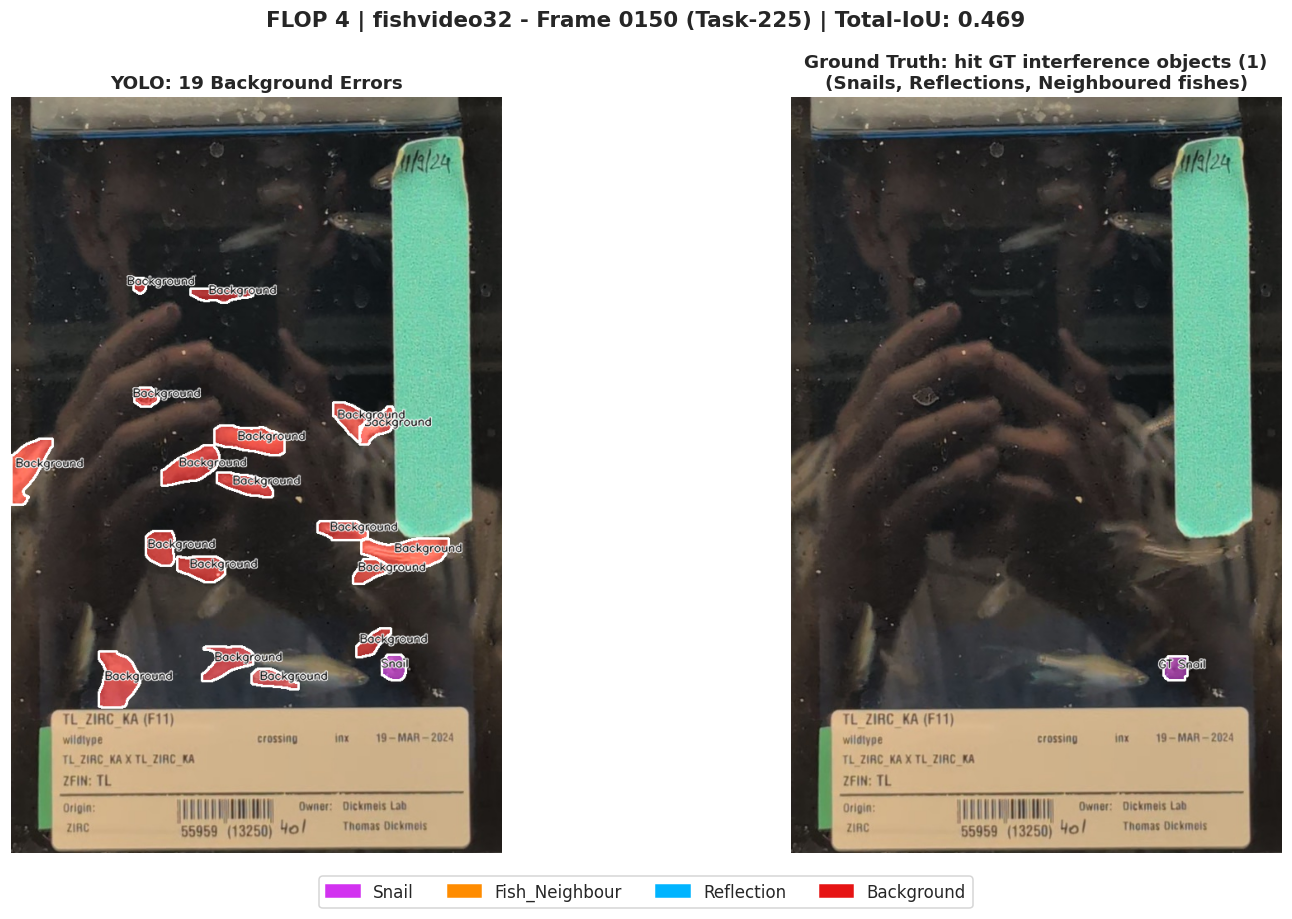

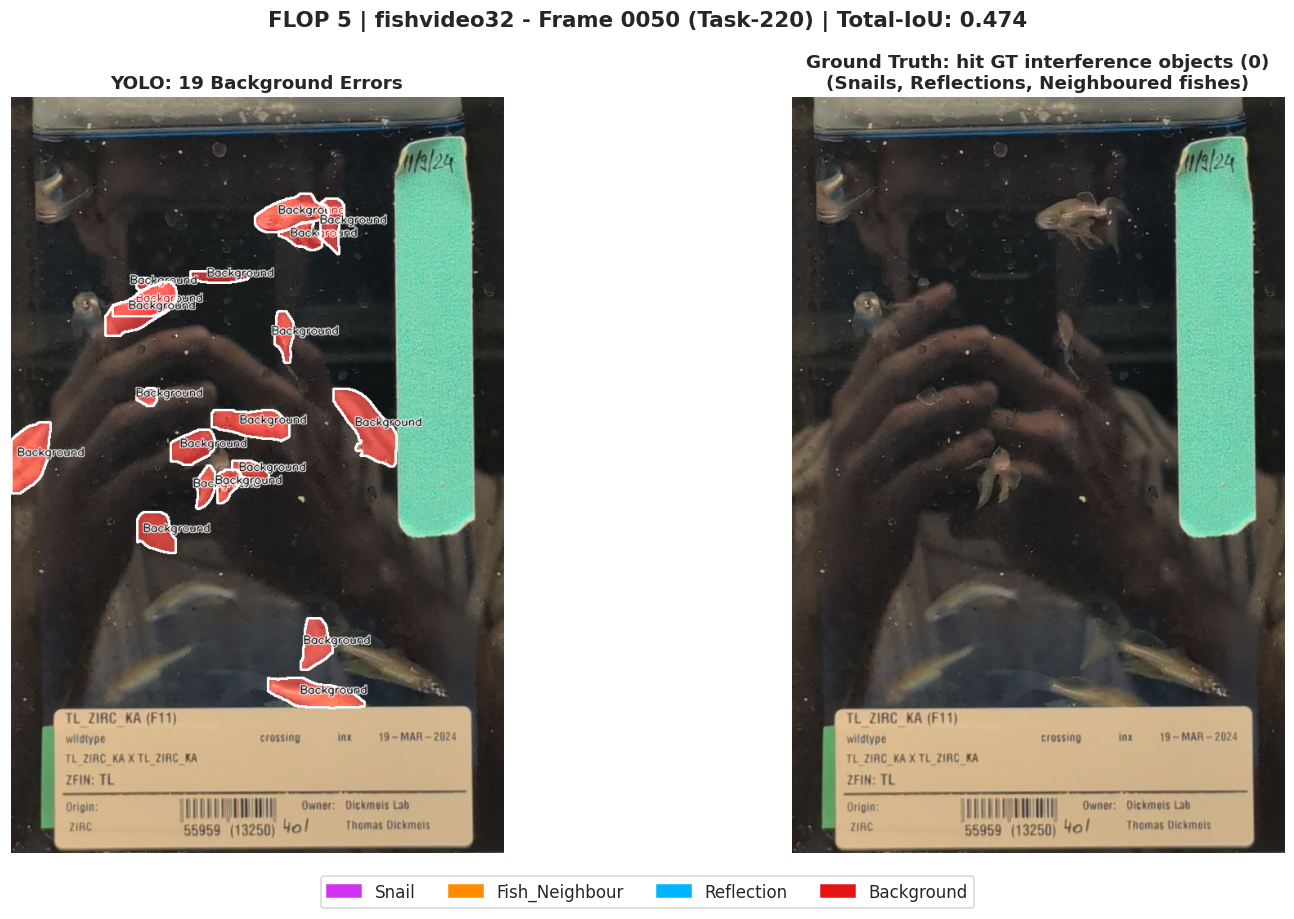

In [16]:
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# Farben für die verschiedenen Background-Fehlerarten (RGB)
BG_ERROR_COLORS = {
    "Snail": (210, 50, 240),  # Lila / Magenta
    "Fish_Neighbour": (255, 140, 0),  # Orange
    "Reflection": (0, 180, 255),  # Cyan
    "Background": (230, 20, 20),  # Rot
}


def render_isolated_background_errors(sample, rank_title=""):
    img_crop = sample["img_crop"]
    h_crop, w_crop = sample["h_crop"], sample["w_crop"]
    img_rgb = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)

    gt_fishes = sample["gt_fish_masks"]
    distractors = sample["distractor_masks"]
    pred_masks = sample["pred_masks"]

    bg_errors = []
    matched_gt_distractor_indices = []

    for pred_m in pred_masks:
        # ignore true positives since we focus on the errors
        if any(mask_iou(pred_m, gt_f) >= 0.5 for gt_f in gt_fishes):
            continue

        best_cat = "Background"
        best_dist_key = None
        best_dist_idx = -1
        max_iou = 0.10

        for key_name, cat_name in [
            ("snail", "Snail"),
            ("neighbour", "Fish_Neighbour"),
            ("reflection", "Reflection"),
        ]:
            for d_idx, dist_m in enumerate(distractors.get(key_name, [])):
                iou = mask_iou(pred_m, dist_m)
                if iou > max_iou:
                    max_iou = iou
                    best_cat = cat_name
                    best_dist_key = key_name
                    best_dist_idx = d_idx

        bg_errors.append((pred_m, best_cat))
        if best_dist_key is not None:
            matched_gt_distractor_indices.append(
                (best_dist_key, best_dist_idx, best_cat)
            )

    # ---------------------------------------------------------
    # 2. left image: isolating the errors made by YOLO
    # ---------------------------------------------------------
    left_yolo_overlay = img_rgb.copy()
    for mask, cat_name in bg_errors:
        color = BG_ERROR_COLORS[cat_name]

        # Transparent masks
        layer = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)
        layer[mask == 1] = color
        left_yolo_overlay = cv2.addWeighted(
            left_yolo_overlay, 1.0, layer, 0.60, 0
        )

        # contour lines
        cnts, _ = cv2.findContours(
            mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.polylines(
            left_yolo_overlay,
            cnts,
            isClosed=True,
            color=(255, 255, 255),
            thickness=2,
        )

        M = cv2.moments(mask)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            label_short = cat_name.split(" ")[0]
            cv2.putText(
                left_yolo_overlay,
                label_short,
                (max(5, cx - 15), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            cv2.putText(
                left_yolo_overlay,
                label_short,
                (max(5, cx - 15), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 0, 0),
                1,
                cv2.LINE_AA,
            )

    # ---------------------------------------------------------
    # 3. Right image: we show only the interference classes from the Ground Truth
    # ---------------------------------------------------------
    right_gt_overlay = img_rgb.copy()
    for key_name, d_idx, cat_name in matched_gt_distractor_indices:
        dist_m = distractors[key_name][d_idx]
        color = BG_ERROR_COLORS[cat_name]

        layer = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)
        layer[dist_m == 1] = color
        right_gt_overlay = cv2.addWeighted(
            right_gt_overlay, 1.0, layer, 0.50, 0
        )

        cnts, _ = cv2.findContours(
            dist_m, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.polylines(
            right_gt_overlay,
            cnts,
            isClosed=True,
            color=(255, 255, 255),
            thickness=2,
        )

        M = cv2.moments(dist_m)
        if M["m00"] > 0:
            cx = int(M["m10"] / M["m00"])
            cy = int(M["m01"] / M["m00"])
            cv2.putText(
                right_gt_overlay,
                f"GT {cat_name.split(' ')[0]}",
                (max(5, cx - 20), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (255, 255, 255),
                2,
                cv2.LINE_AA,
            )
            cv2.putText(
                right_gt_overlay,
                f"GT {cat_name.split(' ')[0]}",
                (max(5, cx - 20), max(15, cy)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.45,
                (0, 0, 0),
                1,
                cv2.LINE_AA,
            )


    fig, axes = plt.subplots(1, 2, figsize=(16, 8), dpi=110)

    axes[0].imshow(left_yolo_overlay)
    axes[0].set_title(
        f"YOLO: {len(bg_errors)} Background Errors",
        fontsize=12,
        fontweight="bold",
    )
    axes[0].axis("off")

    axes[1].imshow(right_gt_overlay)
    axes[1].set_title(
        f"Ground Truth: hit GT interference objects ({len(matched_gt_distractor_indices)})\n(Snails, Reflections, Neighboured fishes)",
        fontsize=12,
        fontweight="bold",
    )
    axes[1].axis("off")

    legend_patches = [
        mpatches.Patch(color=np.array(col) / 255.0, label=name)
        for name, col in BG_ERROR_COLORS.items()
    ]
    fig.legend(
        handles=legend_patches,
        loc="lower center",
        ncol=4,
        fontsize=11,
        bbox_to_anchor=(0.5, -0.05),
    )

    plt.suptitle(
        f"{rank_title} | {sample['video']} - Frame {sample['frame']:04d} (Task-{sample['task_id']}) | Total-IoU: {sample['iou']:.3f}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()


# ---------------------------------------------------------
# TOP 5 & FLOP 5
# ---------------------------------------------------------
# sort by IoU
sorted_samples = sorted(
    evaluated_samples, key=lambda x: x["iou"], reverse=True
)

k = min(5, len(sorted_samples))
top_k = sorted_samples[:k]
flop_k = sorted_samples[-k:][::-1]

print("\n" + "=" * 75)
print(f"       🏆 TOP {k} BEST FRAMES (highest IoU)")
print("=" * 75)
for rank, sample in enumerate(top_k, 1):
    render_isolated_background_errors(sample, rank_title=f"TOP {rank}")

if len(sorted_samples) > 5:
    print("\n" + "=" * 75)
    print(f"       ⚠️ FLOP {k} WORST FRAMES (lowest IoU)")
    print("=" * 75)
    for rank, sample in enumerate(flop_k, 1):
        render_isolated_background_errors(sample, rank_title=f"FLOP {rank}")

# Debugging

### show specific frame yolo vs gt

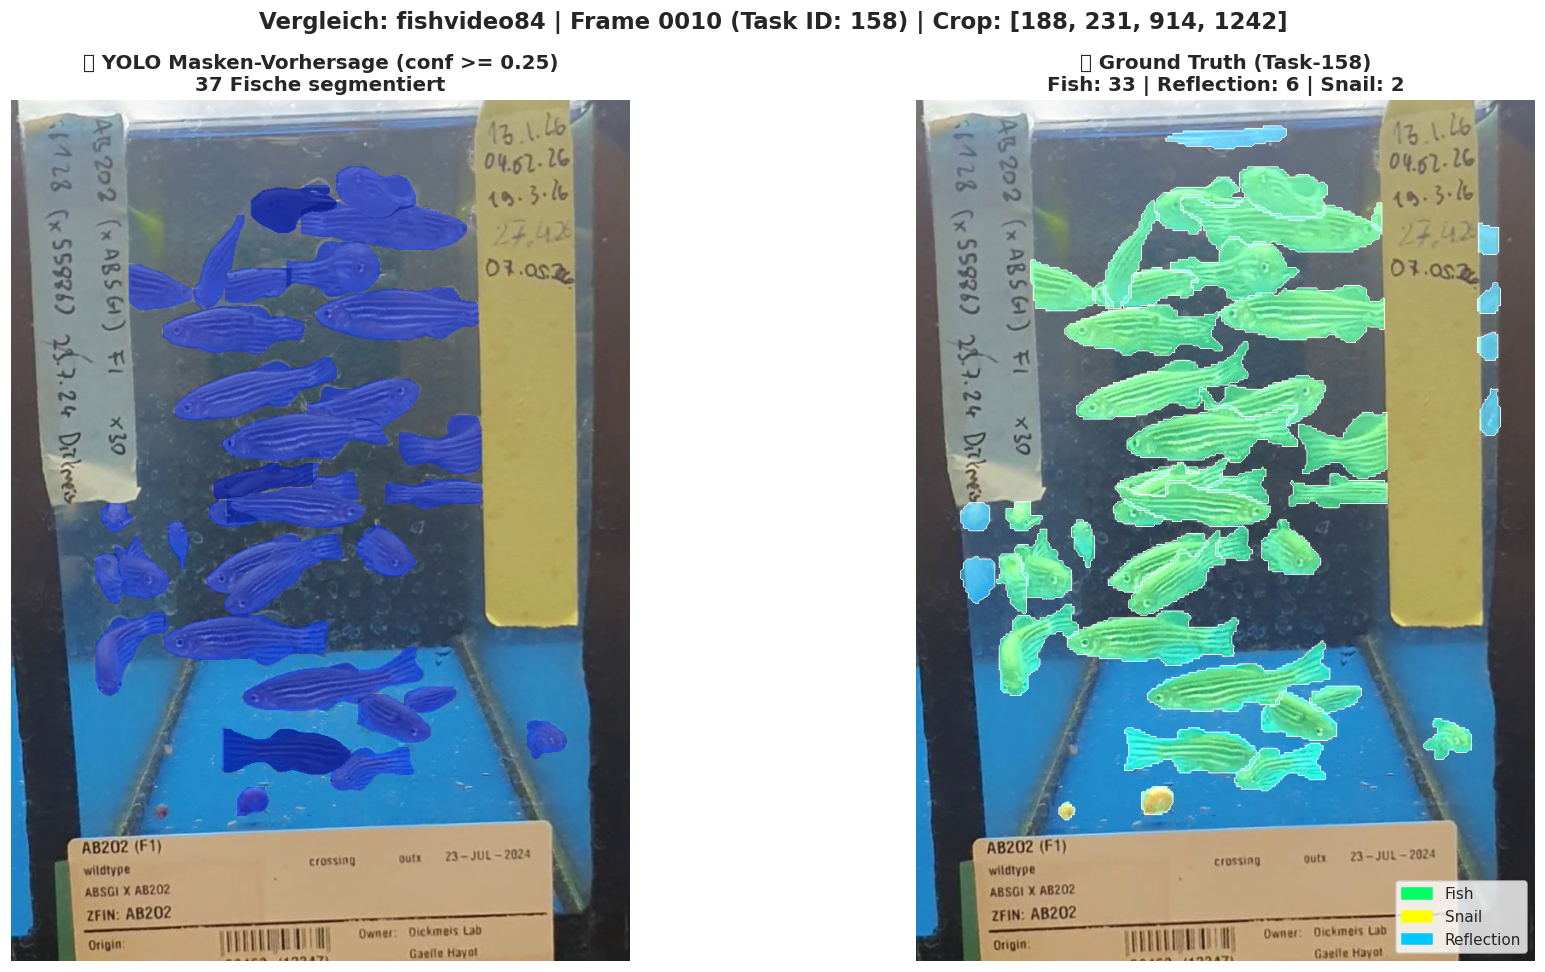

In [10]:
import re
import cv2
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np


def show_frame_comparison(
    video, frame_nr: int, conf_thresh: float = CONF_THRESHOLD
):
    """Zeigt für einen bestimmten Frame den direkten Vergleich zwischen:

    - Links: YOLO Vorhersage (NUR Segmentierungsmasken, OHNE Boxen & Labels)
    - Rechts: Ground Truth (inkl. aller Klassen)
    """
    # 1. Video-Name formatieren
    if isinstance(video, int) or (isinstance(video, str) and video.isdigit()):
        video_name = f"fishvideo{video}"
    else:
        video_name = str(video).replace("_finished", "")

    # 2. Pfade auflösen
    finished_folder = GT_LABELS_DIR / f"{video_name}_finished"
    if not finished_folder.exists():
        finished_folder = GT_LABELS_DIR / video_name

    frames_folder = RECORDINGS_DIR / f"frames_{video_name}"
    if not frames_folder.exists():
        frames_folder = RECORDINGS_DIR / video_name

    # Mapping-Datei (.txt) suchen
    txt_path = GT_LABELS_DIR / f"{video_name}.txt"
    if not txt_path.exists() and finished_folder.exists():
        for tf in finished_folder.glob("*.txt"):
            if not tf.name.endswith("_cut.txt"):
                txt_path = tf
                break

    # Validierung
    if (
        not finished_folder.exists()
        or not frames_folder.exists()
        or not txt_path.exists()
    ):
        print(f"[!] Fehler: Ordner oder Mapping für '{video_name}' nicht gefunden!")
        print(f"    - Finished-Ordner: {finished_folder}")
        print(f"    - Frames-Ordner:   {frames_folder}")
        print(f"    - Mapping-TXT:     {txt_path}")
        return

    # 3. Frame-Nummer auf Task-ID mappen
    with open(txt_path, "r") as f:
        content = f.read()
    frame_numbers = [int(num) for num in re.findall(r"\d+", content)]

    if frame_nr not in frame_numbers:
        print(
            f"[!] Frame {frame_nr} existiert nicht in {txt_path.name}! Verfügbar: {frame_numbers}"
        )
        return

    frame_idx = frame_numbers.index(frame_nr)

    # Alle .npy / .npz Masken nach Task gruppieren
    all_mask_files = sorted(
        list(finished_folder.glob("*.npy"))
        + list(finished_folder.glob("*.npz"))
    )
    task_groups = defaultdict(list)
    for mf in all_mask_files:
        match = re.search(r"task-(\d+)", mf.name)
        if match:
            task_groups[int(match.group(1))].append(mf)

    sorted_tasks = sorted(task_groups.keys())
    if frame_idx >= len(sorted_tasks):
        print(
            f"[!] Kein Task für Index {frame_idx} gefunden (nur {len(sorted_tasks)} Tasks vorhanden)."
        )
        return

    target_task_id = sorted_tasks[frame_idx]
    task_mask_files = task_groups[target_task_id]

    # 4. Bild laden
    img_name = f"{frame_nr:04d}.jpg"
    img_path = frames_folder / img_name
    if not img_path.exists():
        img_path = frames_folder / f"{frame_nr}.jpg"

    img = cv2.imread(str(img_path))
    if img is None:
        print(f"[!] Frame-Bild nicht gefunden: {img_path}")
        return
    h_orig, w_orig = img.shape[:2]

    # 5. Crop-Box aus _cut.txt laden
    x1, y1, x2, y2 = load_crop_box_from_txt(
        finished_folder, video_name, frame_nr, target_task_id, img.shape
    )
    img_crop = img[y1:y2, x1:x2]
    img_rgb = cv2.cvtColor(img_crop, cv2.COLOR_BGR2RGB)
    h_crop, w_crop = img_crop.shape[:2]

    # 6. GT-Masken laden und farbig einzeichnen
    GT_CLASS_COLORS = {
        "Fish": (0, 255, 100),  # Helles Grün
        "Snail": (255, 255, 0),  # Gelb
        "FishNeighbour": (255, 140, 0),  # Orange
        "Reflection": (0, 200, 255),  # Cyan
        "Other": (200, 200, 200),  # Grau
    }

    gt_overlay = img_rgb.copy()
    gt_counts = defaultdict(int)

    for idx, mf in enumerate(task_mask_files):
        data = np.load(mf)
        mask = (
            data[list(data.keys())[0]] if mf.suffix == ".npz" else data
        ).astype(np.uint8)
        if mask.ndim == 3:
            mask = mask.squeeze()
        if mask.shape[:2] != (h_orig, w_orig):
            mask = cv2.resize(
                mask, (w_orig, h_orig), interpolation=cv2.INTER_NEAREST
            )

        mask_crop = (mask[y1:y2, x1:x2] > 0).astype(np.uint8)
        if mask_crop.sum() == 0:
            continue

        name_lower = mf.name.lower()
        if "tag-fisch" in name_lower or "tag-fish" in name_lower:
            cls_name = "Fish"
        elif "tag-snail" in name_lower:
            cls_name = "Snail"
        elif "tag-fishneighbour" in name_lower:
            cls_name = "FishNeighbour"
        elif "tag-reflection" in name_lower:
            cls_name = "Reflection"
        else:
            cls_name = "Other"

        gt_counts[cls_name] += 1
        color = GT_CLASS_COLORS[cls_name]

        # Maske transparent füllen
        layer = np.zeros((h_crop, w_crop, 3), dtype=np.uint8)
        layer[mask_crop == 1] = color
        gt_overlay = cv2.addWeighted(gt_overlay, 1.0, layer, 0.45, 0)

        # Weiße Konturlinie
        cnts, _ = cv2.findContours(
            mask_crop, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
        )
        cv2.polylines(
            gt_overlay, cnts, isClosed=True, color=(255, 255, 255), thickness=1
        )

    # ---------------------------------------------------------
    # 7. YOLO Inferenz & Plot NUR MIT MASKEN (OHNE BOXEN/LABELS)
    # ---------------------------------------------------------
    results = model.predict(
        source=img_crop,
        conf=conf_thresh,
        retina_masks=True,
        verbose=False,
    )

    # Hier: boxes=False, labels=False, conf=False, masks=True
    clean_plot = results[0].plot(
        boxes=False, labels=False, conf=False, masks=True
    )
    pred_plot_rgb = cv2.cvtColor(clean_plot, cv2.COLOR_BGR2RGB)
    num_pred = (
        len(results[0].boxes) if results[0].boxes is not None else 0
    )

    # 8. Nebeneinander darstellen
    fig, axes = plt.subplots(1, 2, figsize=(18, 9), dpi=110)

    # LINKS: YOLO (Nur Masken)
    axes[0].imshow(pred_plot_rgb)
    axes[0].set_title(
        f"🤖 YOLO Masken-Vorhersage (conf >= {conf_thresh})\n{num_pred} Fische segmentiert",
        fontsize=13,
        fontweight="bold",
    )
    axes[0].axis("off")

    # RECHTS: Ground Truth
    gt_info_str = " | ".join([f"{k}: {v}" for k, v in sorted(gt_counts.items())])
    axes[1].imshow(gt_overlay)
    axes[1].set_title(
        f"🎯 Ground Truth (Task-{target_task_id})\n{gt_info_str}",
        fontsize=13,
        fontweight="bold",
    )
    axes[1].axis("off")

    # GT-Farblegende
    legend_patches = [
        mpatches.Patch(color=np.array(col) / 255.0, label=f"{name}")
        for name, col in GT_CLASS_COLORS.items()
        if gt_counts[name] > 0
    ]
    if legend_patches:
        axes[1].legend(
            handles=legend_patches, loc="lower right", fontsize=10, framealpha=0.8
        )

    plt.suptitle(
        f"Vergleich: {video_name} | Frame {frame_nr:04d} (Task ID: {target_task_id}) | Crop: [{x1}, {y1}, {x2}, {y2}]",
        fontsize=15,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()





show_frame_comparison(video=84, frame_nr=10)